Une entreprise possède plusieurs bâtiments équipés de capteurs IoT.
Chaque capteur collecte régulièrement des informations sur la température, l'humidité, la pression,
la consommation énergétique, l'état du capteur, le bâtiment, la date et l'heure de la mesure.
Après avoir utilisé NumPy pour manipuler les données numériques et Pandas pour importer,
nettoyer et analyser le dataset, l'étape suivante consiste à représenter graphiquement les
informations afin d'identifier des tendances, des différences entre bâtiments et des anomalies.

**Partie 1 – Graphique linéaire (Line Plot)**

d'abord importation des données avec pandas 

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/mesures_capteurs.csv")

**1) Afficher l'évolution de la température en fonction du temps, avec le titre, les labels, la légende
et la grille.**

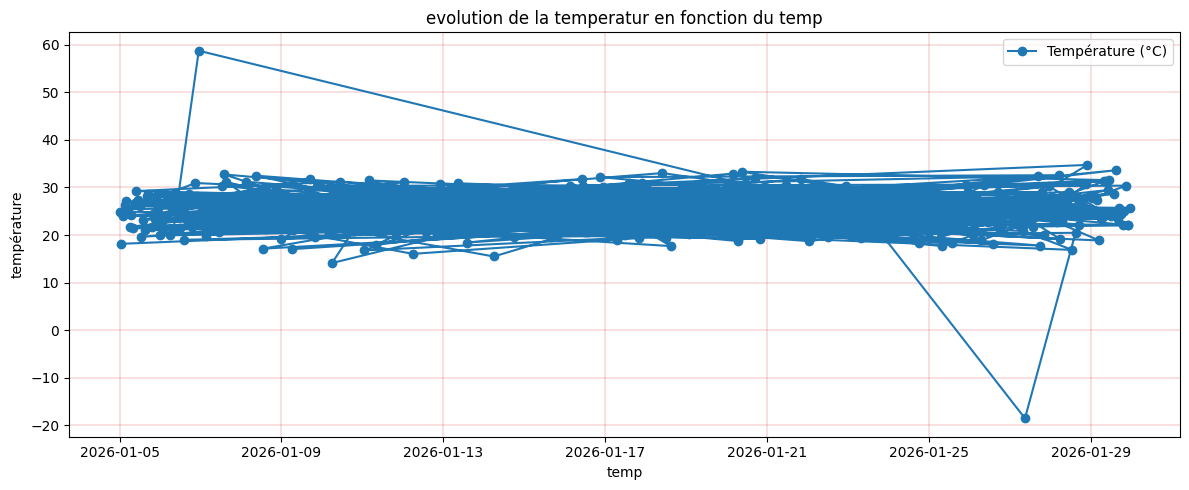

In [38]:
# alors pour afficher cette évolution il faut récuperer d'abord la colonne température et la colonne temp et aprés traçer le graphe
# alors moi j'utilise l'approche POO pour manipuler carrément tous
#donc avant tout j'ai d'abord convertit la colonne dat_heure en datetime pour uine plus pertinent format
#aprés j'ai utilisé le syntaxe de la POO pour ploter la température et la date et ajouter un tire et les deux labels(x&y) ajouter le grid et enfin afficher
#et ajout du label dans le plot et l'appelé avec legend
x= pd.to_datetime(df["date_heure"])
y= df["temperature"]

fig, ax = plt.subplots(figsize=(12,5))

ax.plot(x,y,marker='o',label="Température (°C)")

ax.set_title("evolution de la temperatur en fonction du temp")
ax.set_xlabel("temp")
ax.set_ylabel("température")

ax.grid(True, color="tab:red", linewidth=0.2)
plt.tight_layout()
plt.legend()
plt.show()

**Anomalies visibles :** alors ici on observe quelques pics ponctuels qui sortent nettement du nuage principal de
points (qui oscille grossièrement entre 15 °C et 35 °C) — notamment une valeur très basse
proche de -18 °C et une valeur très haute proche de 58 °C. Ces points isolés, physiquement peu
plausibles pour une température, représente probablement des erreurs de capteur.

**1) Déterminer consommation_batiment qui stocke les consommations moyennes des bâtiments**

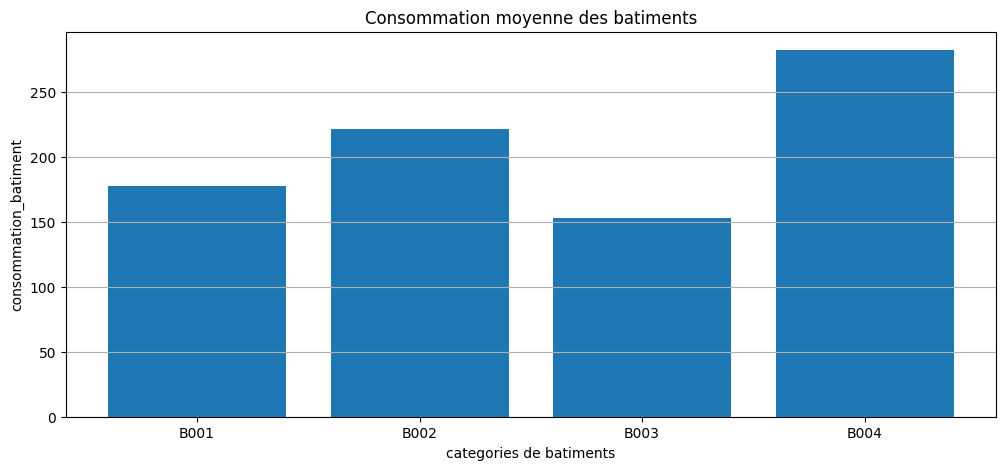

In [ ]:
cons_batiment = df.groupby("batiment")["consommation"].mean()

cons_batiment.index # maitenant ce sera nos categorie
cons_batiment # et là nous aurons nos vaaleurs

fig, ax=plt.subplots(figsize=(12,5))

plt.bar(cons_batiment.index,cons_batiment)
ax.set_title("Consommation moyenne des batiments")
ax.set_xlabel("categories de batiments")
ax.set_ylabel("consommation_batiment")
plt.grid(axis="y") #pour faire les grid dans l'axe des ordonnées

plt.show()


**2) Comparer graphiquement la consommation moyenne des bâtiments**

B002 et B004 consomment au-dessus de la moyenne, B004 étant nettement le plus énergivore du groupe.
B001 et B003 sont en dessous, B003 étant le plus économe.
L'écart entre le bâtiment le plus et le moins consommateur est au alentours de 130 unités, ce qui est trés significatif — ça vaut le coup de creuser pourquoi B004 consomme.

**3) Comparer la consommation moyenne des bâtiments avec un graphique horizontal**

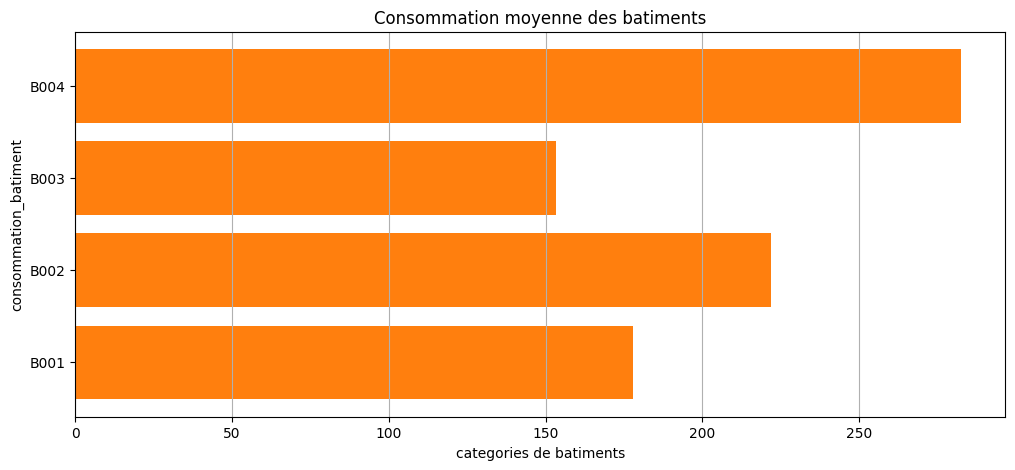

In [ ]:
cons_batiment = df.groupby("batiment")["consommation"].mean()

cons_batiment.index # maitenant ce sera nos categorie
cons_batiment # et là nous aurons nos vaaleurs

fig, ax=plt.subplots(figsize=(12,5))

plt.barh(cons_batiment.index,cons_batiment,color="tab:orange")
ax.set_title("Consommation moyenne des batiments")
ax.set_xlabel("categories de batiments")
ax.set_ylabel("consommation_batiment")
plt.grid(axis="x") #pour faire les grid dans l'axe des abcisses

plt.show()

**Quand un graphique horizontal est-il plus lisible ?** Dès que les noms des catégories
sont longs (ils ne se chevauchent pas et n'ont pas besoin d'être inclinés), quand il y a
beaucoup de catégories à lister (plus confortable à lire de haut en bas), ou quand on veut
présenter un classement, car l'œil lit naturellement une liste de haut en bas comme un
classement.

**Partie 3 – Histogramme**

**1) Afficher la distribution des températures en divisant la plage des données en 20 classes et en
affichant uniquement les lignes horizontales de la grille**

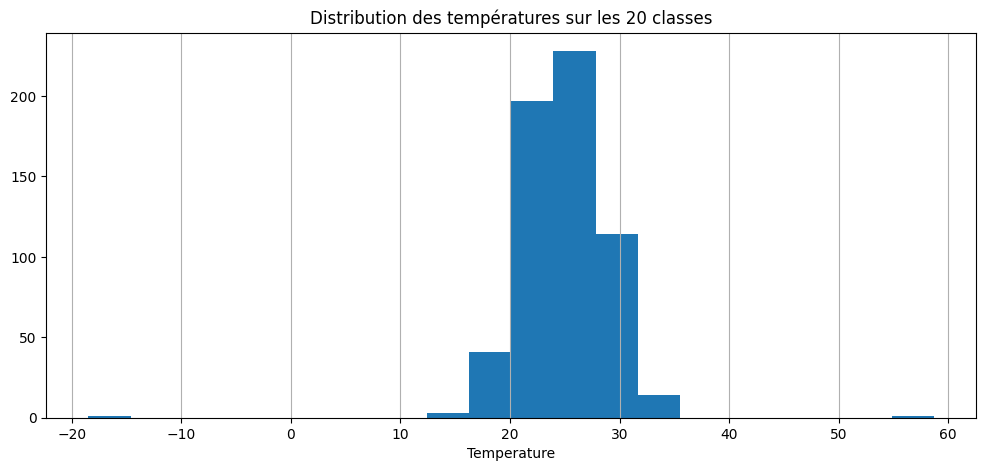

In [ ]:
fig, ax=plt.subplots(figsize=(12,5))

#alors pour traçer un histogramme nous avons juste besoins de la catégorie et du nombre de classe (la plage)
plt.hist(df["temperature"], bins=20)
ax.set_title("Distribution des températures sur les 20 classes")
ax.set_xlabel("Temperature")
plt.grid(axis="x") #pour faire les grid dans l'axe des abcisses

plt.show()

**2) Analyse du graphique :**


**a) Pour la concentration** : la majorité des mesures se regroupe entre 20 °C et 30 °C, autour d'une
  classe centrale la plus fréquente proche de 24-25 °C.

**b) La symétrie** : la distribution paraît globalement assez symétrique autour de son pic central,
  en forme de cloche.

**c) Les valeurs éloignées** : quelques barres isolées, très basses en hauteur, apparaissent loin à
  gauche (vers -18 °C) et loin à droite (vers 58 °C).

**d) Les valeurs aberrantes** : ces barres isolées, séparées du reste par des classes vides,
  correspondent aux anomalies déjà repérées dans le graphique linéaire de la Partie 1.

**3) Afficher la distribution de la consommation en divisant la plage des données en 20 classes**

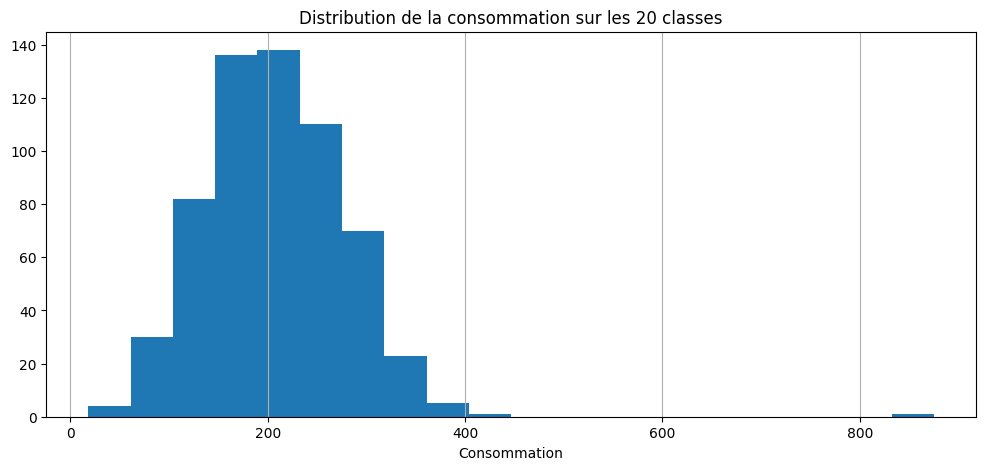

In [51]:
fig, ax=plt.subplots(figsize=(12,5))

#alors pour traçer un histogramme nous avons juste besoins de la catégorie et du nombre de classe (la plage)
plt.hist(df["consommation"], bins=20)
ax.set_title("Distribution de la consommation sur les 20 classes")
ax.set_xlabel("Consommation")
plt.grid(axis="x") #pour faire les grid dans l'axe des abcisses

plt.show()

**a) Modification du nombre de classes à 10**

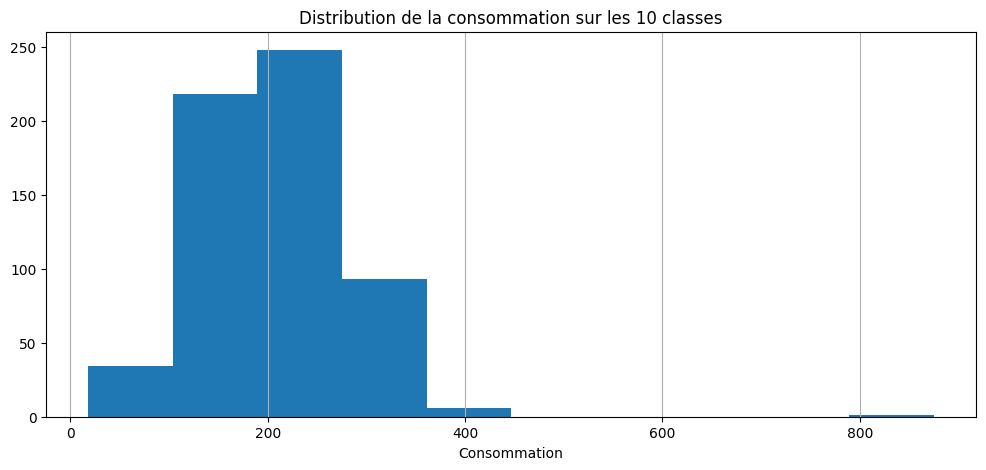

In [53]:
fig, ax=plt.subplots(figsize=(12,5))

#alors pour traçer un histogramme nous avons juste besoins de la catégorie et du nombre de classe (la plage)
plt.hist(df["consommation"], bins=10)
ax.set_title("Distribution de la consommation sur les 10 classes")
ax.set_xlabel("Consommation")
plt.grid(axis="x") #pour faire les grid dans l'axe des abcisses

plt.show()